<a href="https://colab.research.google.com/github/vinayani-vv/DSA0406-FODS/blob/main/exp_16_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
exp 16

In [2]:
import pandas as pd
from collections import Counter

reviews_data = pd.DataFrame({
    "review": [
        "good product",
        "very good product",
        "product is good",
        "excellent product"
    ]
})

all_words = []

for review in reviews_data["review"]:
    words = review.lower().split()
    all_words.extend(words)

word_frequency = Counter(all_words)

print("Word Frequency Distribution:")
for word, count in word_frequency.items():
    print(word, ":", count)

Word Frequency Distribution:
good : 3
product : 4
very : 1
is : 1
excellent : 1


In [ ]:
exp 17

Saving fods data.csv to fods data.csv
Enter N: 5
Top 5 most frequent words:
good : 7
product : 6
service : 4
love : 3
excellent : 3


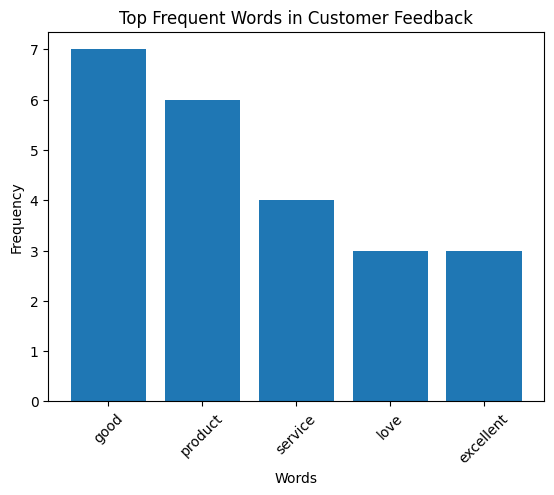

In [3]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

stop_words = {
    "the", "is", "and", "a", "an", "to", "of", "in",
    "this", "it", "i", "with", "for", "very"
}

all_words = []

for feedback in data["feedback"]:
    feedback = feedback.lower()
    feedback = re.sub(r'[^\w\s]', '', feedback)
    words = feedback.split()

    for word in words:
        if word not in stop_words:
            all_words.append(word)

frequency = Counter(all_words)

N = int(input("Enter N: "))

top_words = frequency.most_common(N)

print("Top", N, "most frequent words:")
for word, count in top_words:
    print(word, ":", count)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.bar(words, counts)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top Frequent Words in Customer Feedback")
plt.xticks(rotation=45)
plt.show()

In [ ]:
exp 18

Saving fods exp18.csv to fods exp18.csv
Mean:
Age     40.000000
%Fat    29.444444
dtype: float64

Median:
Age     40.0
%Fat    29.5
dtype: float64

Standard Deviation:
Age     10.677078
%Fat     7.114378
dtype: float64


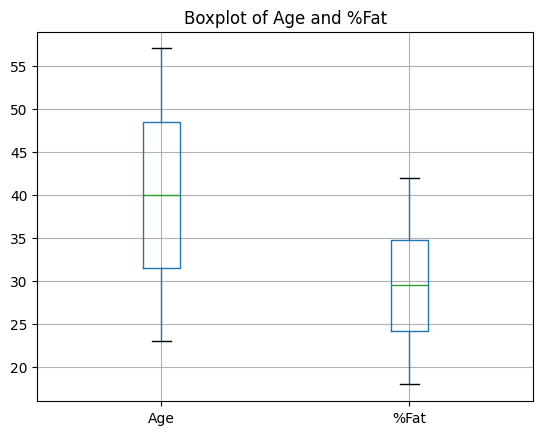

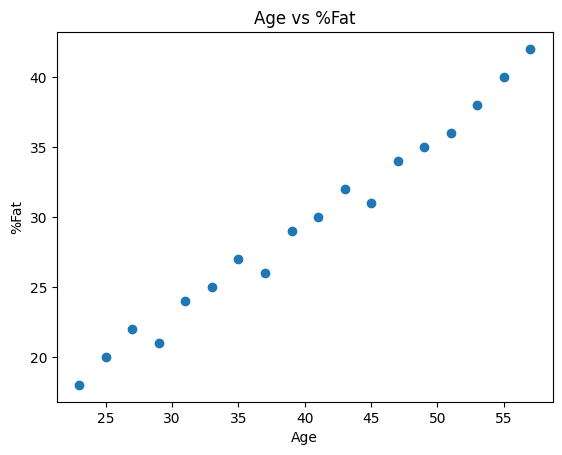

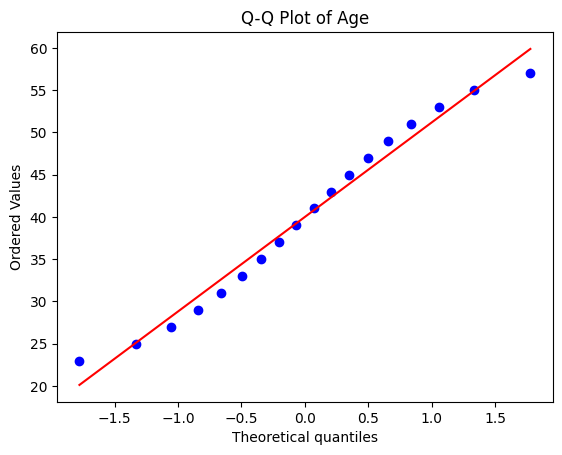

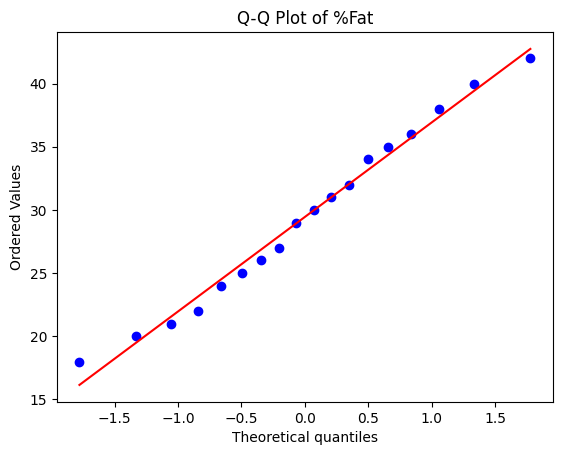

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

print("Mean:")
print(data.mean())

print("\nMedian:")
print(data.median())

print("\nStandard Deviation:")
print(data.std())

# Boxplot
data.boxplot(column=["Age", "%Fat"])
plt.title("Boxplot of Age and %Fat")
plt.show()

# Scatter plot
plt.scatter(data["Age"], data["%Fat"])
plt.xlabel("Age")
plt.ylabel("%Fat")
plt.title("Age vs %Fat")
plt.show()

# Q-Q plot for Age
stats.probplot(data["Age"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Age")
plt.show()

# Q-Q plot for %Fat
stats.probplot(data["%Fat"], dist="norm", plot=plt)
plt.title("Q-Q Plot of %Fat")
plt.show()

In [ ]:
exp 19

In [5]:
import pandas as pd
import scipy.stats as stats
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

drug = data[data["Group"] == "Drug"]["Reduction"]
placebo = data[data["Group"] == "Placebo"]["Reduction"]

drug_mean = drug.mean()
placebo_mean = placebo.mean()

drug_ci = stats.t.interval(
    0.95,
    len(drug) - 1,
    loc=drug_mean,
    scale=stats.sem(drug)
)

placebo_ci = stats.t.interval(
    0.95,
    len(placebo) - 1,
    loc=placebo_mean,
    scale=stats.sem(placebo)
)

print("95% Confidence Interval for Drug:")
print(drug_ci)

print("\n95% Confidence Interval for Placebo:")
print(placebo_ci)

Saving exp 19 fods.csv to exp 19 fods.csv
95% Confidence Interval for Drug:
(np.float64(11.817799142311271), np.float64(14.582200857688727))

95% Confidence Interval for Placebo:
(np.float64(4.743214781014749), np.float64(6.656785218985251))


In [ ]:
exp 20

In [6]:
import pandas as pd
from scipy.stats import ttest_ind
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

A = data[data["Design"] == "A"]["Conversion_Rate"]
B = data[data["Design"] == "B"]["Conversion_Rate"]

t_stat, p_value = ttest_ind(A, B)

print("Mean Conversion Rate - Design A:", A.mean())
print("Mean Conversion Rate - Design B:", B.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("There is a statistically significant difference.")
else:
    print("There is no statistically significant difference.")

Saving exp 20 fods.csv to exp 20 fods.csv
Mean Conversion Rate - Design A: 0.13200000000000003
Mean Conversion Rate - Design B: 0.087
T-statistic: 6.05557760421947
P-value: 1.0059496143796055e-05
There is a statistically significant difference.
